In [21]:
# Apr 25, 2020
# increse data by adding videos from youtube
import keras
keras.__version__

'2.15.0'

In [22]:
from keras import models
from keras import layers
from keras import metrics
from keras import optimizers

import numpy as np
import json
import os
import csv
import pandas as pd
import tensorflow_addons as tfa

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


In [6]:
# read json 2-d pose as data, without using: 
#     {15, "REye"},
#     {16, "LEye"},
#     {17, "REar"},
#     {18, "LEar"}

ur_basepath1 = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/fall_UR/fall-cam0'
ur_basepath2 = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/adl_UR'
mc_fall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/MCdataset/mc_fall'
mc_notfall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/MCdataset/mc-notfall'
youtube_fall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/Youtube/resize/resize_fall'
youtube_notfall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/Youtube/resize/resize_notfall'

def input_data(basepath):
  data = []
  entries = os.listdir(basepath)
  for entry in entries:
    path = os.path.join(basepath, entry)
    frames = os.listdir(path)
    for frame in frames:
      frame_path = os.path.join(path, frame)
      with open(frame_path, mode='r') as json_file:
        people_dict = json.load(json_file)
        people = people_dict["people"]
        pose_keypoints_2d = []
        # fill missing data as 0
        if len(people) == 0:
          pose_keypoints_2d = [0] * 63
        else:
          full_pose = people[0].get("pose_keypoints_2d")
          pose_keypoints_2d = full_pose[:45] + full_pose[57:]
         
        pose_keypoints_2d.append(frame.split('.')[0])
        # each pose_keypoints_2d: 
        #    [431.949, 196.241, 0.0564434, 437.194, 187.749, 0.552267,...'fall-06-cam0_000000000065_keypoints']
        # OR [123.949, 283.241, 0.0564434, 437.194, 187.749, 0.552267,...'43_000000000000_keypoints']
        data.append(pose_keypoints_2d)        
  return data

In [7]:
# read the data of UR dataset  
# http://fenix.univ.rzeszow.pl/~mkepski/ds/uf.html
ur_data1 = input_data(ur_basepath1)
print(len(ur_data1))

ur_data2 = input_data(ur_basepath2)
print(len(ur_data2))
 
ur_data = ur_data1 + ur_data2
print("finish UR dataset, and the length of UR dataset: ", len(ur_data))

df1 = pd.DataFrame.from_records(ur_data)
df1.to_csv (r'/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/ur_data.csv', index = False, header=False)

# read the data of MC dataset
# http://www.iro.umontreal.ca/~labimage/Dataset/
mc_fall_data = input_data(mc_fall_path)
print("finish mc fall data. the length of mc-fall dataset: ", len(mc_fall_data))


df2 = pd.DataFrame.from_records(mc_fall_data)
df2.to_csv(r'/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/mc_fall_data.csv', index = False, header=False)

mc_notfall_data = input_data(mc_notfall_path)
print("length of mc_not_fall dataset: ", len(mc_notfall_data))

df3 = pd.DataFrame.from_records(mc_notfall_data)
df3.to_csv(r'/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/mc_notfall_data.csv', index = False, header=False)


FileNotFoundError: [Errno 2] No such file or directory: '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/fall_UR/fall-cam0'

In [9]:
# read the data of youtube dataset
youtube_fall_data = input_data(youtube_fall_path)
print("length of youtube_fall dataset: ", len(youtube_fall_data))

df4 = pd.DataFrame.from_records(youtube_fall_data)
df4.to_csv(r'/content/drive/My Drive/636project/youtube_fall_data.csv', index = False, header=False)

youtube_notfall_data = input_data(youtube_notfall_path)
print("length of youtube_notfall dataset: ", len(youtube_notfall_data))

df5 = pd.DataFrame.from_records(youtube_notfall_data)
df5.to_csv(r'/content/drive/My Drive/636project/youtube_notfall_data.csv', index = False, header=False)

print('finish loading youtube dataset')

length of youtube_fall dataset:  1867
length of youtube_notfall dataset:  4213
finish loading youtube dataset


In [23]:
# read the video data csv,
# it is faster than running the above code each time

ur_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/ur_data.csv'
mc_fall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/mc_fall_data.csv'
mc_notfall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/mc_notfall_data.csv'
youtube_fall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/youtube_fall_data.csv'
youtube_notfall_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/youtube_notfall_data.csv'

def read_data(path):
  video_data = []
  with open(path, mode='r') as csv_file:
    reader = csv.reader(csv_file)
    for row in reader:
      video_data.append(row)
  return video_data

ur_data = read_data(ur_path)
mc_fall_data = read_data(mc_fall_path)
mc_notfall_data = read_data(mc_notfall_path)
youtube_fall_data = read_data(youtube_fall_path)
youtube_notfall_data = read_data(youtube_notfall_path)


print(ur_data[0])
print(mc_fall_data[0])
print(mc_notfall_data[0])
print(youtube_fall_data[0])
print(youtube_notfall_data[0])

['520.972', '128.178', '0.833728', '544.571', '130.782', '0.739747', '540.636', '132.754', '0.726633', '553.086', '154.999', '0.800764', '541.285', '166.155', '0.742877', '549.144', '129.467', '0.745059', '572.703', '155.035', '0.841464', '543.266', '171.369', '0.817947', '572.067', '169.415', '0.607432', '564.874', '166.16', '0.534525', '526.875', '181.191', '0.862423', '554.389', '217.851', '0.612664', '577.962', '170.732', '0.619415', '535.402', '188.398', '0.760066', '560.284', '220.479', '0.65847', '545.882', '232.266', '0.604373', '553.078', '232.915', '0.532739', '566.184', '222.453', '0.655722', '541.939', '229.002', '0.399536', '541.943', '227.687', '0.344383', '560.285', '217.223', '0.153482', 'fall-16-cam0_000000000016_keypoints']
['504.171', '238.019', '0.119379', '481.995', '237.979', '0.647555', '471.564', '247.106', '0.6547', '485.918', '299.334', '0.780827', '525.04', '307.158', '0.770417', '495.036', '228.845', '0.474206', '519.863', '220.995', '0.283234', '539.41', '2

In [24]:
# normalize data according to the size of videos in different dataset
def normalize(list, width, height):
  for record in list:
    for i in range(0, 63, 3):
        record[i] = float(record[i])/ width
        record[i + 1] = float(record[i + 1]) / height

normalize(ur_data, 640, 240)
normalize(mc_fall_data, 720, 480)
normalize(mc_notfall_data, 720, 480)
normalize(youtube_fall_data, 640, 360)
normalize(youtube_notfall_data, 640, 360)


In [25]:
print(ur_data[0])
print(mc_fall_data[0])
print(mc_notfall_data[0])
print(youtube_fall_data[0])
print(youtube_notfall_data[0])

[0.81401875, 0.534075, '0.833728', 0.8508921875000001, 0.544925, '0.739747', 0.8447437499999999, 0.5531416666666666, '0.726633', 0.864196875, 0.6458291666666667, '0.800764', 0.8457578124999999, 0.6923125, '0.742877', 0.8580375, 0.5394458333333334, '0.745059', 0.8948484375, 0.6459791666666667, '0.841464', 0.848853125, 0.7140375, '0.817947', 0.8938546875, 0.7058958333333333, '0.607432', 0.882615625, 0.6923333333333334, '0.534525', 0.8232421875, 0.7549625, '0.862423', 0.8662328125000001, 0.9077125, '0.612664', 0.903065625, 0.7113833333333334, '0.619415', 0.8365656250000001, 0.7849916666666666, '0.760066', 0.87544375, 0.9186625, '0.65847', 0.8529406249999999, 0.9677749999999999, '0.604373', 0.864184375, 0.9704791666666667, '0.532739', 0.8846624999999999, 0.9268875, '0.655722', 0.8467796875, 0.954175, '0.399536', 0.8467859375, 0.9486958333333334, '0.344383', 0.8754453124999999, 0.9050958333333334, '0.153482', 'fall-16-cam0_000000000016_keypoints']
[0.7002375, 0.49587291666666666, '0.119379'

In [26]:
# read target label of UR dataset. 

target = []
path1 = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/urfall-cam0-falls.csv'
path2 = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/urfall-cam0-adls.csv'
# in these csv of UR dataset, 
# '-1' means person is not lying, '1' means person is lying on the ground; '0' is temporary pose, when person "is falling"

def input_fall(path):
  with open(path, mode='r') as csv_file:
    reader = csv.reader(csv_file)
    for row in reader:
      record = []
      record.append(row[0])
      record.append(row[1])
      label = row[2]
      if label == '1' or label == '0':
        record.append(1)        
      else:
        record.append(0)
      # each record: [<video_id>, <frame_id>, label], eg: ['fall-17', '22', 0] 
      target.append(record)

# though laying in the video, but it is not fall, so I mark 0 as label
def input_adl(path):
  with open(path, mode='r') as csv_file:
    reader = csv.reader(csv_file)
    for row in reader:
      record = []
      record.append(row[0])
      record.append(row[1])
      record.append(0)
      target.append(record)

input_fall(path1)
print("falls of UR dataset", len(target))

input_adl(path2)

df = pd.DataFrame.from_records(target)
df.to_csv (r'/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/target_data.csv', index = False, header=False)


falls of UR dataset 2995


In [27]:
# make dictionary of target of ur dataset
target_csv_path = '/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/data/csv_file/target_data.csv'
idx = 0
idx_dict = {}

with open(target_csv_path, mode='r') as csv_file:
  reader = csv.reader(csv_file)
  for row in reader:
    # each row: [<video_id>, <frame_id>, label], eg: ['fall-17', '22', 0] 
    idx_dict['.'.join(row[:2])] = idx  # {'fall-17.22' : 112}
    idx += 1

In [28]:
# match body landmark data with label data of ur dataset
bodylandmark = []
label = []
frame_name = []

for landmark in ur_data:
  video_name = landmark[-1].split('_')  # 'fall-01-cam0_000000000004'
  a = video_name[0].split('-')
  video_type = a[0] # 'fall'
  video_id = a[1]   # '01'
  frame_id = str(int(video_name[1])) # '000000000004' become '4'
  try:
    a = '.'.join([video_id, frame_id])
    b = '-'.join([video_type, a])
    label.append(target[idx_dict[b]][-1])
    bl = landmark[:-1]
    # convert string into float
    bl = list(map(float,bl))
    bodylandmark.append(bl)
    frameName = landmark[-1]
    frame_name.append(frameName)
  except:
    continue

print("bodylandmark record sample of ur dataset:" )
print(bodylandmark[0])
print("label of ur dataset: ", len(label))
print("bodylandmark of ur dataset: ", len(bodylandmark))
print(frame_name[0])

bodylandmark record sample of ur dataset:
[0.81401875, 0.534075, 0.833728, 0.8508921875000001, 0.544925, 0.739747, 0.8447437499999999, 0.5531416666666666, 0.726633, 0.864196875, 0.6458291666666667, 0.800764, 0.8457578124999999, 0.6923125, 0.742877, 0.8580375, 0.5394458333333334, 0.745059, 0.8948484375, 0.6459791666666667, 0.841464, 0.848853125, 0.7140375, 0.817947, 0.8938546875, 0.7058958333333333, 0.607432, 0.882615625, 0.6923333333333334, 0.534525, 0.8232421875, 0.7549625, 0.862423, 0.8662328125000001, 0.9077125, 0.612664, 0.903065625, 0.7113833333333334, 0.619415, 0.8365656250000001, 0.7849916666666666, 0.760066, 0.87544375, 0.9186625, 0.65847, 0.8529406249999999, 0.9677749999999999, 0.604373, 0.864184375, 0.9704791666666667, 0.532739, 0.8846624999999999, 0.9268875, 0.655722, 0.8467796875, 0.954175, 0.399536, 0.8467859375, 0.9486958333333334, 0.344383, 0.8754453124999999, 0.9050958333333334, 0.153482]
label of ur dataset:  11475
bodylandmark of ur dataset:  11475
fall-16-cam0_000000

In [29]:
# add data of MC dataset to the whole dataset
# For MC dataset, all frames in fall data should be label 1, 
# and all frames in notfall data should be label 0.
for record in mc_fall_data:
  bl = record[:-1]
  bl = list(map(float,bl))
  bodylandmark.append(bl)
  label.append(1)
  frameName = record[-1]
  frame_name.append(frameName)

for record in mc_notfall_data:
  bl = record[:-1]
  bl = list(map(float,bl))
  bodylandmark.append(bl)
  label.append(0)
  frameName = record[-1]
  frame_name.append(frameName)


In [30]:
# add data of youtube dataset to the whole dataset
# For youtube dataset, all frames in fall data should be label 1, 
# and all frames in notfall data should be label 0.
for record in youtube_fall_data:
  bl = record[:-1]
  bl = list(map(float,bl))
  bodylandmark.append(bl)
  label.append(1)
  frameName = record[-1]
  frame_name.append(frameName)

for record in youtube_notfall_data:
  bl = record[:-1]
  bl = list(map(float,bl))
  bodylandmark.append(bl)
  label.append(0)
  frameName = record[-1]
  frame_name.append(frameName)


In [31]:
# make bodylandmark and label to be a same data frame
all_data = []

for i in range(len(bodylandmark)):
  all_data.append([label[i]])
  all_data[i] = all_data[i] + bodylandmark[i]

print(all_data[0])
print(len(all_data))
print(len(all_data[0]))

[0, 0.81401875, 0.534075, 0.833728, 0.8508921875000001, 0.544925, 0.739747, 0.8447437499999999, 0.5531416666666666, 0.726633, 0.864196875, 0.6458291666666667, 0.800764, 0.8457578124999999, 0.6923125, 0.742877, 0.8580375, 0.5394458333333334, 0.745059, 0.8948484375, 0.6459791666666667, 0.841464, 0.848853125, 0.7140375, 0.817947, 0.8938546875, 0.7058958333333333, 0.607432, 0.882615625, 0.6923333333333334, 0.534525, 0.8232421875, 0.7549625, 0.862423, 0.8662328125000001, 0.9077125, 0.612664, 0.903065625, 0.7113833333333334, 0.619415, 0.8365656250000001, 0.7849916666666666, 0.760066, 0.87544375, 0.9186625, 0.65847, 0.8529406249999999, 0.9677749999999999, 0.604373, 0.864184375, 0.9704791666666667, 0.532739, 0.8846624999999999, 0.9268875, 0.655722, 0.8467796875, 0.954175, 0.399536, 0.8467859375, 0.9486958333333334, 0.344383, 0.8754453124999999, 0.9050958333333334, 0.153482]
35279
64


In [32]:
# know the majority and minority
fall = label.count(1)
not_fall = label.count(0)
print(fall)
print(not_fall)

13128
22151


In [33]:
# up-sampling to make the data balance
# Separate majority and minority classes
df = pd.DataFrame.from_records(all_data)
header = ['label']
for i in range(63):
  header.append(i)

df.columns = header
df_majority = df[df.label==0]
df_minority = df[df.label==1]
print("before re-sampling, not fall vs fall: ")
print(df['label'].value_counts())

from sklearn.utils import resample
print("begin to re sample...")
# Upsample minority class
df_minority_upsampled = resample(df_minority, 
                                 replace=True,      # sample with replacement
                                 n_samples=not_fall)    # to match majority class
                                  
# Combine majority class with upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])
 
print("after re-sampling...")
# Display new class counts
df_upsampled.label.value_counts()

before re-sampling, not fall vs fall: 
label
0    22151
1    13128
Name: count, dtype: int64
begin to re sample...
after re-sampling...


label
0    22151
1    22151
Name: count, dtype: int64

In [34]:
all_data = df_upsampled.values

print(all_data[0])
print(len(all_data[0]))
print("number of all data:", len(all_data))

[0.         0.81401875 0.534075   0.833728   0.85089219 0.544925
 0.739747   0.84474375 0.55314167 0.726633   0.86419687 0.64582917
 0.800764   0.84575781 0.6923125  0.742877   0.8580375  0.53944583
 0.745059   0.89484844 0.64597917 0.841464   0.84885312 0.7140375
 0.817947   0.89385469 0.70589583 0.607432   0.88261563 0.69233333
 0.534525   0.82324219 0.7549625  0.862423   0.86623281 0.9077125
 0.612664   0.90306562 0.71138333 0.619415   0.83656563 0.78499167
 0.760066   0.87544375 0.9186625  0.65847    0.85294062 0.967775
 0.604373   0.86418438 0.97047917 0.532739   0.8846625  0.9268875
 0.655722   0.84677969 0.954175   0.399536   0.84678594 0.94869583
 0.344383   0.87544531 0.90509583 0.153482  ]
64
number of all data: 44302


In [35]:
# split data into train and test set
np.random.shuffle(all_data)
split_point = len(all_data) // 9
print("split point:", split_point)
test_data = all_data[:split_point]
train_data = all_data[split_point:]

print("number of test data:", len(test_data))
print("number of train data:",len(train_data))

print(train_data[0])

split point: 4922
number of test data: 4922
number of train data: 39380
[0.         0.6299125  0.2312975  0.8663     0.63501094 0.31570833
 0.894686   0.6115375  0.31299292 0.752672   0.60127812 0.3976075
 0.637758   0.60229844 0.46575417 0.649863   0.65755781 0.31583167
 0.850243   0.66670156 0.40852792 0.731552   0.66778906 0.48494167
 0.59794    0.63503125 0.50402083 0.655189   0.6196875  0.50401667
 0.603789   0.62481875 0.635      0.563612   0.62583906 0.75230417
 0.475962   0.65037188 0.50401667 0.642743   0.65033438 0.62682917
 0.574534   0.64732031 0.74137083 0.361029   0.64629531 0.77136667
 0.154734   0.65447813 0.7686125  0.165646   0.64422969 0.75772917
 0.215639   0.63093438 0.77684583 0.322977   0.62274219 0.77675
 0.335507   0.62787031 0.76319583 0.297822  ]


In [18]:
# solution 1: train model using lstm
from tensorflow.keras.layers import LSTM
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from numpy import array
from tensorflow.keras.models import Sequential

def scheduler(epoch):
  if epoch < 10:
    return 0.001
  else:
    return 0.001 * np.exp(0.1 * (10 - epoch))

x_train = []
y_train = []

for record in train_data:
  x_train.append(record[1:])
  label = int(record[0])
  y_train.append(label) 

def train_lstm_model(x_train, y_train):
  x_train = array(x_train)
  x_train = x_train.reshape((len(x_train), 1, len(x_train[0])))
  print("x_train.shape", x_train.shape)
  print(x_train[0])

  y_train = array(y_train)
  print("y_train.shape", y_train.shape)

  # imrpove log: use batch size 16 and add one more lstm layer

  lstm_model = Sequential()
  lstm_model.add(LSTM(16, 
                input_shape=(1, 63),
                return_sequences=True))
  lstm_model.add(LSTM(16, ))
  lstm_model.add(layers.Dense(1, activation='sigmoid'))
  lstm_model.compile(optimizer='rmsprop',
                loss='binary_crossentropy',
                metrics=['acc',
                        metrics.AUC(), 
                        metrics.FalseNegatives(),
                        metrics.Recall(),
                        metrics.Precision(),
                        metrics.FalseNegatives(),
                        metrics.TrueNegatives(),
                        metrics.FalsePositives(),
                        metrics.TruePositives()])
  lstm_history = lstm_model.fit(x_train, y_train,
                      epochs=100,
                      batch_size=16,
                      validation_split=0.2,
                      callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5),
                      callbacks.LearningRateScheduler(scheduler)])
  print("finish training lstm model")
  return lstm_model, lstm_history

lstm_model, lstm_history = train_lstm_model(x_train, y_train)

x_train.shape (17248, 1, 63)
[[0.64629531 0.25300833 0.76132    0.64833438 0.3131125  0.844044
  0.63093906 0.3157075  0.826944   0.62577969 0.38412417 0.839396
  0.62477344 0.44958333 0.82076    0.665725   0.31297167 0.809454
  0.67490156 0.37855417 0.754047   0.6800375  0.43584167 0.644778
  0.651425   0.4521625  0.766511   0.64215781 0.45492917 0.726379
  0.64629375 0.5559375  0.748818   0.65145781 0.64037917 0.803396
  0.66366406 0.44949167 0.717166   0.6657125  0.5585375  0.767202
  0.66679219 0.66220833 0.792379   0.66673594 0.68682917 0.745964
  0.67187656 0.68411667 0.708303   0.66573906 0.66506667 0.634285
  0.65037813 0.66499583 0.78838    0.64526719 0.6595625  0.728414
  0.65649844 0.64324167 0.6652    ]]
y_train.shape (17248,)


2025-07-04 09:28:35.264587: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-04 09:28:35.282134: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-04 09:28:35.282225: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Epoch 1/100


2025-07-04 09:28:36.774470: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905


  1/863 [..............................] - ETA: 28:02 - loss: 0.6929 - acc: 0.4375 - auc: 0.6270 - false_negatives: 8.0000 - recall: 0.1111 - precision: 0.5000 - false_negatives_1: 8.0000 - true_negatives: 6.0000 - false_positives: 1.0000 - true_positives: 1.0000

2025-07-04 09:28:37.439523: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f97b414b570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-04 09:28:37.439539: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-07-04 09:28:37.451653: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751596117.498167    6828 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


863/863 [==============================] - 11s 11ms/step - loss: 0.5022 - acc: 0.7662 - auc: 0.8387 - false_negatives: 1236.0000 - recall: 0.8215 - precision: 0.7409 - false_negatives_1: 1236.0000 - true_negatives: 4882.0000 - false_positives: 1990.0000 - true_positives: 5690.0000 - val_loss: 0.4670 - val_acc: 0.7765 - val_auc: 0.8694 - val_false_negatives: 158.0000 - val_recall: 0.9080 - val_precision: 0.7179 - val_false_negatives_1: 158.0000 - val_true_negatives: 1119.0000 - val_false_positives: 613.0000 - val_true_positives: 1560.0000 - lr: 0.0010
Epoch 2/100
863/863 [==============================] - 9s 11ms/step - loss: 0.4000 - acc: 0.8125 - auc: 0.8972 - false_negatives: 1030.0000 - recall: 0.8513 - precision: 0.7911 - false_negatives_1: 1030.0000 - true_negatives: 5315.0000 - false_positives: 1557.0000 - true_positives: 5896.0000 - val_loss: 0.3864 - val_acc: 0.8151 - val_auc: 0.9039 - val_false_negatives: 230.0000 - val_recall: 0.8661 - val_precision: 0.7848 - val_false_negati

863/863 [==============================] - 9s 10ms/step - loss: 0.2297 - acc: 0.8988 - auc: 0.9656 - false_negatives: 445.0000 - recall: 0.9357 - precision: 0.8719 - false_negatives_1: 445.0000 - true_negatives: 5920.0000 - false_positives: 952.0000 - true_positives: 6481.0000 - val_loss: 0.2380 - val_acc: 0.8907 - val_auc: 0.9643 - val_false_negatives: 98.0000 - val_recall: 0.9430 - val_precision: 0.8531 - val_false_negatives_1: 98.0000 - val_true_negatives: 1453.0000 - val_false_positives: 279.0000 - val_true_positives: 1620.0000 - lr: 1.6530e-04
Epoch 30/100
863/863 [==============================] - 9s 11ms/step - loss: 0.2282 - acc: 0.8986 - auc: 0.9661 - false_negatives: 465.0000 - recall: 0.9329 - precision: 0.8737 - false_negatives_1: 465.0000 - true_negatives: 5938.0000 - false_positives: 934.0000 - true_positives: 6461.0000 - val_loss: 0.2331 - val_acc: 0.8930 - val_auc: 0.9649 - val_false_negatives: 114.0000 - val_recall: 0.9336 - val_precision: 0.8628 - val_false_negatives_

In [19]:
lstm_model.summary()
# lstm_model.save("/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/Model_execution/new_model_improved_lstm.h5")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 16)             5120      
                                                                 
 lstm_1 (LSTM)               (None, 16)                2112      
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 7249 (28.32 KB)
Trainable params: 7249 (28.32 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
import matplotlib.pyplot as plt
import numpy as np

def plotting_training(history):
    # Helper to find the correct metric key, accounting for Keras's numbering (e.g., 'acc_1', 'auc_1')
    def get_metric_key(base_name, history_dict):
        # Find all keys that contain the base_name
        matching_keys = [k for k in history_dict.keys() if base_name in k]
        
        if not matching_keys:
            return None # No metric found

        # Prioritize the exact base_name if it exists
        if base_name in matching_keys:
            return base_name
        
        # If not, try to find the one that looks like 'base_name_X'
        # Sort them to get the one with the lowest number if multiple exist
        numbered_keys = sorted([k for k in matching_keys if k.replace(base_name, '').startswith('_') and k.replace(base_name + '_', '').isdigit()], 
                               key=lambda x: int(x.split('_')[-1]))
        
        if numbered_keys:
            return numbered_keys[0] # Return the first numbered key (e.g., 'precision_1')
        
        # Fallback if other patterns exist (less common)
        return matching_keys[0] # Just return the first one found if no clear pattern

    # Find the keys for train and validation metrics
    acc_key = get_metric_key('acc', history.history)
    val_acc_key = get_metric_key('val_acc', history.history)
    
    loss_key = get_metric_key('loss', history.history)
    val_loss_key = get_metric_key('val_loss', history.history)

    precision_key = get_metric_key('precision', history.history)
    val_precision_key = get_metric_key('val_precision', history.history)

    recall_key = get_metric_key('recall', history.history)
    val_recall_key = get_metric_key('val_recall', history.history)

    auc_key = get_metric_key('auc', history.history)
    val_auc_key = get_metric_key('val_auc', history.history)

    # --- Start plotting ---

    # 1. Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1) # 1 row, 2 columns, position 1
    if acc_key and val_acc_key:
        plt.plot(history.history[acc_key])
        plt.plot(history.history[val_acc_key])
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
    else:
        print(f"Accuracy metric ('{acc_key}', '{val_acc_key}') not found in history.")

    # 2. Plot training & validation loss values
    plt.subplot(1, 2, 2) # 1 row, 2 columns, position 2
    if loss_key and val_loss_key:
        loss = history.history[loss_key]
        val_loss = history.history[val_loss_key]
        epochs = range(1, len(loss) + 1)
        plt.plot(epochs, loss, 'bo', label="Training Loss")
        plt.plot(epochs, val_loss, 'b', label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.ylim(0.0, 0.5) # Keep y-limit for easier comparison
        plt.legend()
    else:
        print(f"Loss metric ('{loss_key}', '{val_loss_key}') not found in history.")
    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.show()

    # 3. Plot training & validation Precision values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    if precision_key and val_precision_key:
        plt.plot(history.history[precision_key])
        plt.plot(history.history[val_precision_key])
        plt.title('Model Precision')
        plt.ylabel('Precision')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
    else:
        print(f"Precision metric ('{precision_key}', '{val_precision_key}') not found in history.")

    # 4. Plot training & validation Recall values
    plt.subplot(1, 2, 2)
    if recall_key and val_recall_key:
        plt.plot(history.history[recall_key])
        plt.plot(history.history[val_recall_key])
        plt.title('Model Recall')
        plt.ylabel('Recall')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
    else:
        print(f"Recall metric ('{recall_key}', '{val_recall_key}') not found in history.")
    plt.tight_layout()
    plt.show()

    # 5. Plot training & validation AUC values
    plt.figure(figsize=(6, 5)) # Only one subplot needed
    if auc_key and val_auc_key:
        plt.plot(history.history[auc_key])
        plt.plot(history.history[val_auc_key])
        plt.title('Model AUC-ROC')
        plt.ylabel('AUC')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
    else:
        print(f"AUC metric ('{auc_key}', '{val_auc_key}') not found in history.")
    plt.tight_layout()
    plt.show()

# Example usage (after you've trained your model and have the history object)
# lstm_model, lstm_history = train_lstm_model(x_train, y_train)
# plotting_training(lstm_history)

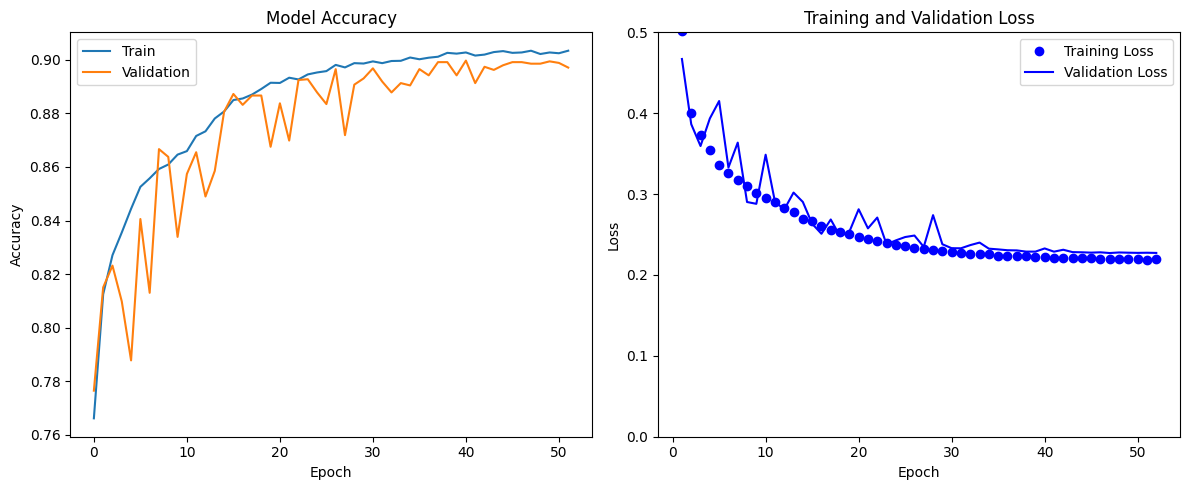

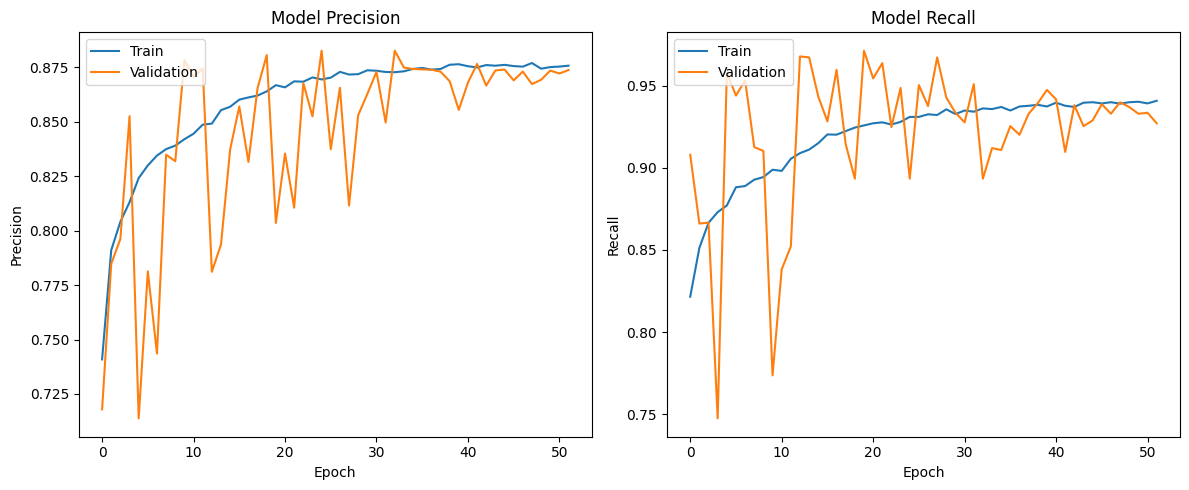

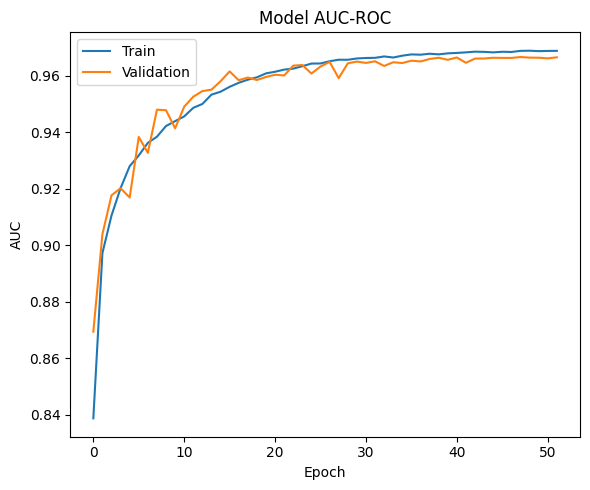

In [21]:
plotting_training(lstm_history)

68/68 [==============================] - 0s 3ms/step - loss: 0.2325 - acc: 0.8975 - auc: 0.9639 - false_negatives: 74.0000 - recall: 0.9301 - precision: 0.8700 - false_negatives_1: 74.0000 - true_negatives: 951.0000 - false_positives: 147.0000 - true_positives: 984.0000
[0.23247140645980835, 0.8974953889846802, 0.9638705849647522, 74.0, 0.9300566911697388, 0.8700265288352966, 74.0, 951.0, 147.0, 984.0]
68/68 [==============================] - 0s 1ms/step

=== Báo cáo Hiệu suất Mô hình trên Tập TEST ===
Tổng số mẫu trong tập TEST: 2156
Số mẫu 'Ngã' (Label 1): 1058
Số mẫu 'Không Ngã' (Label 0): 1098
--------------------------------------------------
Test Loss (từ Keras evaluate): 0.2325
Test Accuracy (từ Keras evaluate): 0.8975
Test AUC-ROC (từ Keras evaluate): 0.9639

--- Ma trận nhầm lẫn ---
True Positives (TP): 984
True Negatives (TN): 951
False Positives (FP): 147
False Negatives (FN): 74
--------------------------------------------------
Accuracy (Manual): 0.8975
Precision (Manual):

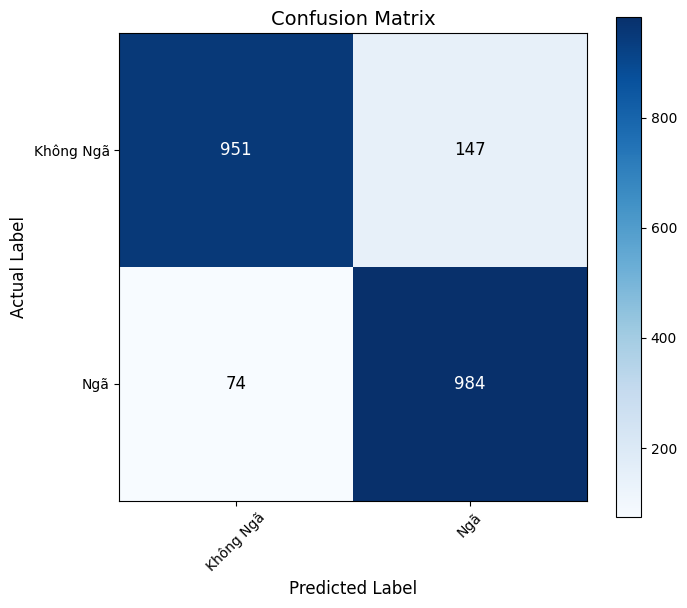

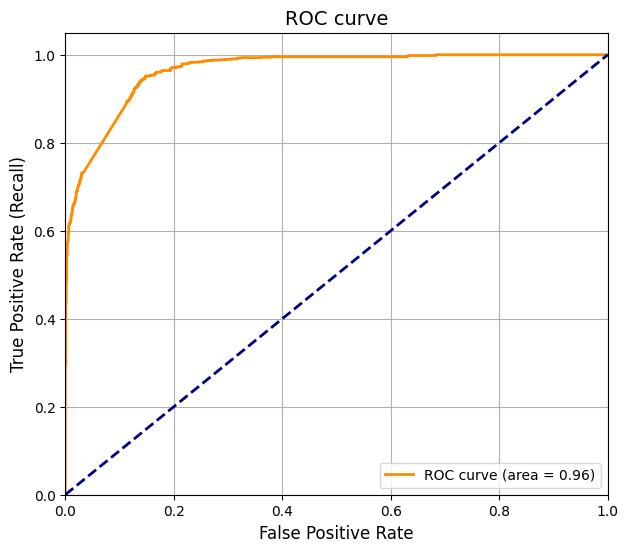

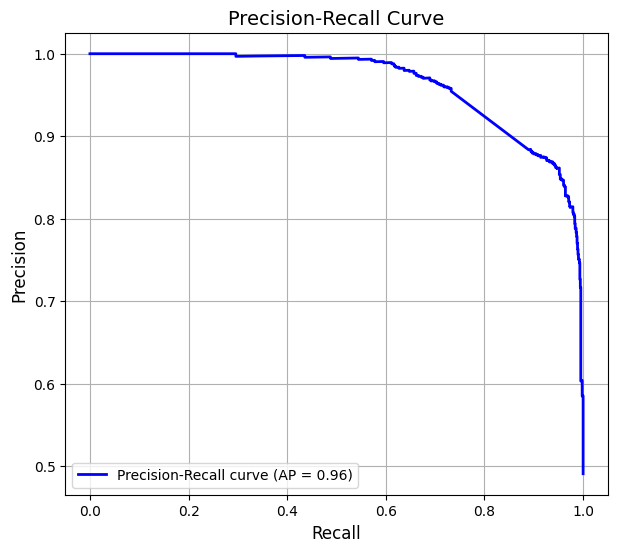

In [22]:
# # test 
# # for lstm
# x_test = []
# y_test = []

# for record in test_data:
#   x_test.append(record[1:])
#   label = int(record[0])
#   y_test.append(label) 

# x_test = array(x_test)
# x_test = x_test.reshape((len(x_test), 1, len(x_test[0])))

# y_test = array(y_test)

# test_score = lstm_model.evaluate(x_test, y_test)
# print(test_score)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score, roc_auc_score
import numpy as np

# --- Bước 1: Chuẩn bị dữ liệu Test ---
# Đảm bảo bạn đã có test_data từ một nguồn độc lập, chưa từng được mô hình nhìn thấy.
# Ví dụ:
# test_data = your_function_to_load_test_data()

x_test_raw = []
y_test_raw = []

for record in test_data:
    x_test_raw.append(record[1:])
    label = int(record[0])
    y_test_raw.append(label)

x_test = np.array(x_test_raw)
y_test = np.array(y_test_raw)

# RẤT QUAN TRỌNG: Áp dụng cùng phép biến đổi (reshape, scaling) như x_train
# Nếu bạn đã dùng scaler cho x_train, hãy áp dụng nó cho x_test
# Ví dụ:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler() # Tạo lại scaler hoặc sử dụng scaler đã fit trên train_data
# # scaler.fit(your_train_data_before_reshape) # Nếu bạn chưa lưu scaler, hãy fit lại trên train_data
# x_test_scaled = scaler.transform(x_test)
# x_test_reshaped = x_test_scaled.reshape((len(x_test_scaled), 1, x_test_scaled.shape[1]))

# Giả sử x_test đã được xử lý đúng dạng (số_mẫu, 1, số_features)
# Kiểm tra lại input_shape của mô hình LSTM của bạn là (1, 63)
# thì x_test phải có dạng (số_mẫu, 1, 63)
# x_test = x_test.reshape((len(x_test), 1, x_test.shape[1])) # x_test.shape[1] sẽ là 63 nếu đúng

x_test = x_test.reshape((len(x_test), 1, len(x_test[0])))

# --- Bước 2: Đánh giá mô hình bằng model.evaluate() ---
# Lấy các metric từ quá trình compile
# Chỉ lấy các metric không bị trùng lặp và có ý nghĩa rõ ràng từ evaluate
test_results_from_evaluate = lstm_model.evaluate(x_test, y_test, verbose=1) # verbose=1 để xem tiến trình
# Bạn có thể in tên các metric để chắc chắn
# print(lstm_model.metrics_names)
print(test_results_from_evaluate)

# --- Bước 3: Tính toán các metric chi tiết từ dự đoán thô (Recommended) ---

# 1. Dự đoán xác suất trên tập kiểm tra
y_pred_proba = lstm_model.predict(x_test)

# 2. Chuyển xác suất thành nhãn dự đoán (ngưỡng 0.5 là mặc định)
y_pred_labels = (y_pred_proba > 0.5).astype(int)

# 3. Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_labels)
# cm.ravel() trả về TN, FP, FN, TP theo thứ tự này
TN, FP, FN, TP = cm.ravel()

# --- Báo cáo Text Các Metric Chính ---
print("\n" + "="*50)
print("=== Báo cáo Hiệu suất Mô hình trên Tập TEST ===")
print("="*50)
print(f"Tổng số mẫu trong tập TEST: {len(y_test)}")
print(f"Số mẫu 'Ngã' (Label 1): {np.sum(y_test == 1)}")
print(f"Số mẫu 'Không Ngã' (Label 0): {np.sum(y_test == 0)}")
print("-" * 50)

print(f"Test Loss (từ Keras evaluate): {test_results_from_evaluate[0]:.4f}")
print(f"Test Accuracy (từ Keras evaluate): {test_results_from_evaluate[1]:.4f}")
print(f"Test AUC-ROC (từ Keras evaluate): {test_results_from_evaluate[2]:.4f}") # Lấy AUC đầu tiên

print("\n--- Ma trận nhầm lẫn ---")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print("-" * 50)

# Tính toán các Metric chính xác hơn từ TP, TN, FP, FN
# Đây là các metric mà bạn nên ưu tiên để đánh giá
accuracy_manual = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_manual = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0
auc_score_manual = roc_auc_score(y_test, y_pred_proba) # Tính lại AUC để đảm bảo từ y_pred_proba

print(f"Accuracy (Manual): {accuracy_manual:.4f}")
print(f"Precision (Manual): {precision_manual:.4f}")
print(f"Recall (Độ nhạy - Rất quan trọng cho Phát hiện Ngã): {recall_manual:.4f}")
print(f"F1-Score (Manual): {f1_manual:.4f}")
print(f"AUC-ROC Score (Manual): {auc_score_manual:.4f}")
print("="*50)

# --- Trực quan hóa các Metric quan trọng ---

# Hàm vẽ Ma trận nhầm lẫn
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(7, 6)) # Tăng kích thước hình
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=10)
    plt.yticks(tick_marks, classes, fontsize=10)

    fmt = 'd' # Định dạng số nguyên
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center", fontsize=12,
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

# Hàm vẽ đường cong ROC
def plot_roc_curve(y_test, y_pred_proba, title='Receiver Operating Characteristic (ROC) Curve'):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True)
    plt.show()

# Hàm vẽ đường cong Precision-Recall
def plot_precision_recall_curve(y_test, y_pred_proba, title='Precision-Recall Curve'):
    precision_points, recall_points, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_points, precision_points)
    plt.figure(figsize=(7, 6))
    plt.plot(recall_points, precision_points, color='blue', lw=2, label=f'Precision-Recall curve (AP = {pr_auc:.2f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(True)
    plt.show()

# --- Gọi các hàm vẽ biểu đồ ---
class_names = ['Không Ngã', 'Ngã'] # Đặt tên lớp cho dễ hiểu
plot_confusion_matrix(cm, classes=class_names, title='Confusion Matrix')
plot_roc_curve(y_test, y_pred_proba, title='ROC curve')
plot_precision_recall_curve(y_test, y_pred_proba, title= 'Precision-Recall Curve')

In [36]:
# solution 2: train model using CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from numpy import array
from tensorflow.keras.models import Sequential

def scheduler(epoch):
  if epoch < 10:
    return 0.001
  else:
    return 0.001 * np.exp(0.1 * (10 - epoch))

x_train = []
y_train = []

for record in train_data:
  x_train.append(record[1:])
  label = int(record[0])
  y_train.append(label) 

def train_cnn_model(x_train, y_train):
  x_train = array(x_train)
  x_train = x_train.reshape((len(x_train), 3, int(len(x_train[0])/3), 1))

  y_train = array(y_train)

  #create model
  cnn_model = Sequential()
  cnn_model.add(Conv2D(64, 
                  kernel_size=3, 
                  activation='relu', 
                  input_shape=(3,21,1), 
                  padding='same'))
  cnn_model.add(layers.BatchNormalization(1))
  cnn_model.add(Conv2D(64, 
                  kernel_size=3, 
                  activation='relu', 
                  padding='same'))
  cnn_model.add(layers.BatchNormalization(1))
  cnn_model.add(MaxPooling2D(2,2))
  cnn_model.add(Flatten())
  cnn_model.add(Dense(512, activation = 'relu')) 
  cnn_model.add(Dense(1, activation='sigmoid'))

  # compile and fit
  cnn_model.compile(optimizer='Adam',
                loss='binary_crossentropy',
                metrics=['acc', 
                        metrics.AUC(), 
                        metrics.FalseNegatives(),
                        metrics.Recall(),
                        metrics.Precision(),
                        metrics.FalseNegatives(),
                        metrics.TrueNegatives(),
                        metrics.FalsePositives(),
                        metrics.TruePositives()])
  cnn_history = cnn_model.fit(x_train, y_train,
                      epochs=100,
                      batch_size=16,
                      validation_split=0.2,
                      callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5),
                      callbacks.LearningRateScheduler(scheduler)])
    
  print("finish training cnn model")
  return cnn_model, cnn_history


cnn_model, cnn_history = train_cnn_model(x_train, y_train)

2025-07-09 23:50:32.113495: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-09 23:50:32.218672: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-09 23:50:32.218993: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Epoch 1/100


2025-07-09 23:50:33.955233: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2025-07-09 23:50:36.790385: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f3ed3044010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-09 23:50:36.790452: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-07-09 23:50:36.969593: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752079837.442117    3547 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1969/1969 [==============================] - 26s 10ms/step - loss: 0.2652 - acc: 0.8915 - auc: 0.9574 - false_negatives: 1489.0000 - recall: 0.9057 - precision: 0.8811 - false_negatives_1: 1489.0000 - true_negatives: 13787.0000 - false_positives: 1929.0000 - true_positives: 14299.0000 - val_loss: 0.1827 - val_acc: 0.9239 - val_auc: 0.9809 - val_false_negatives: 168.0000 - val_recall: 0.9568 - val_precision: 0.8962 - val_false_negatives_1: 168.0000 - val_true_negatives: 3557.0000 - val_false_positives: 431.0000 - val_true_positives: 3720.0000 - lr: 0.0010
Epoch 2/100
1969/1969 [==============================] - 19s 10ms/step - loss: 0.1687 - acc: 0.9302 - auc: 0.9819 - false_negatives: 872.0000 - recall: 0.9448 - precision: 0.9184 - false_negatives_1: 872.0000 - true_negatives: 14390.0000 - false_positives: 1326.0000 - true_positives: 14916.0000 - val_loss: 0.1526 - val_acc: 0.9377 - val_auc: 0.9858 - val_false_negatives: 208.0000 - val_recall: 0.9465 - val_precision: 0.9286 - val_false

1969/1969 [==============================] - 18s 9ms/step - loss: 0.0637 - acc: 0.9705 - auc: 0.9964 - false_negatives: 91.0000 - recall: 0.9942 - precision: 0.9494 - false_negatives_1: 91.0000 - true_negatives: 14879.0000 - false_positives: 837.0000 - true_positives: 15697.0000 - val_loss: 0.0930 - val_acc: 0.9615 - val_auc: 0.9934 - val_false_negatives: 51.0000 - val_recall: 0.9869 - val_precision: 0.9384 - val_false_negatives_1: 51.0000 - val_true_negatives: 3736.0000 - val_false_positives: 252.0000 - val_true_positives: 3837.0000 - lr: 6.7032e-04
Epoch 16/100
1969/1969 [==============================] - 18s 9ms/step - loss: 0.0636 - acc: 0.9705 - auc: 0.9963 - false_negatives: 127.0000 - recall: 0.9920 - precision: 0.9512 - false_negatives_1: 127.0000 - true_negatives: 14913.0000 - false_positives: 803.0000 - true_positives: 15661.0000 - val_loss: 0.0859 - val_acc: 0.9634 - val_auc: 0.9940 - val_false_negatives: 38.0000 - val_recall: 0.9902 - val_precision: 0.9390 - val_false_negat

In [37]:
cnn_model.summary()
# cnn_model.save("/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/Model_execution/new_model_improved_cnn.h5")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 3, 21, 64)         640       
                                                                 
 batch_normalization (Batch  (None, 3, 21, 64)         12        
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 3, 21, 64)         36928     
                                                                 
 batch_normalization_1 (Bat  (None, 3, 21, 64)         12        
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 1, 10, 64)         0         
 D)                                                              
                                                        

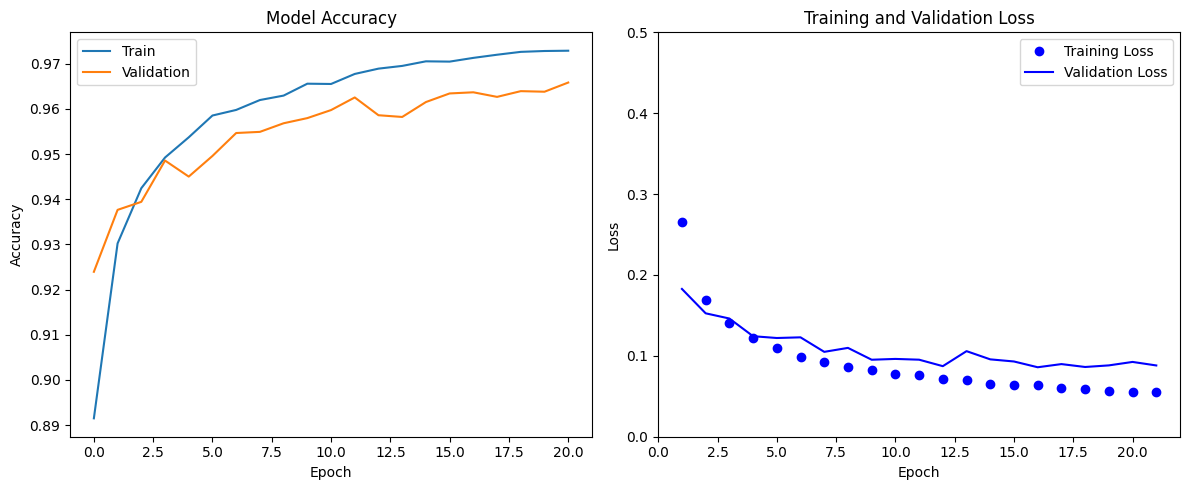

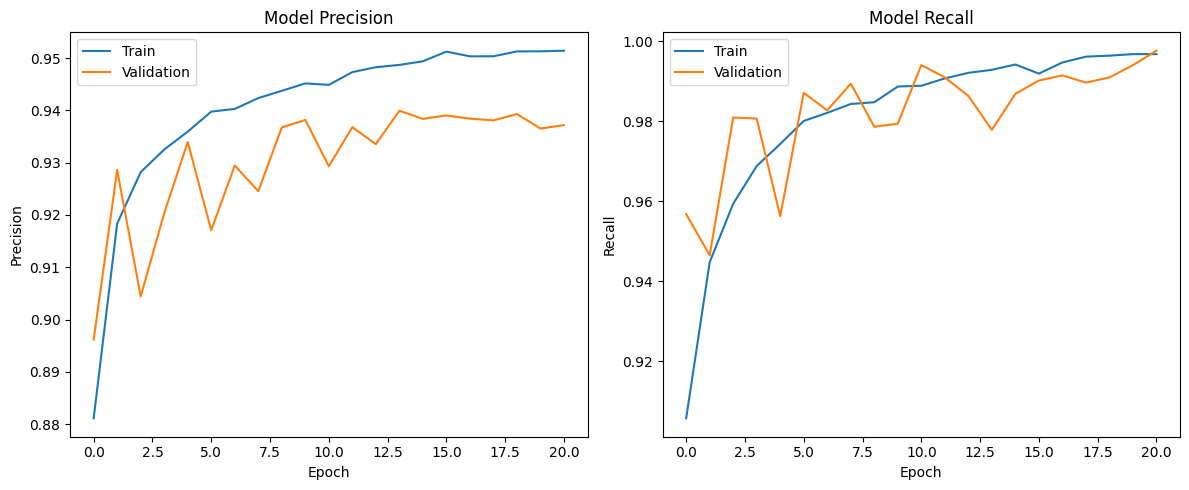

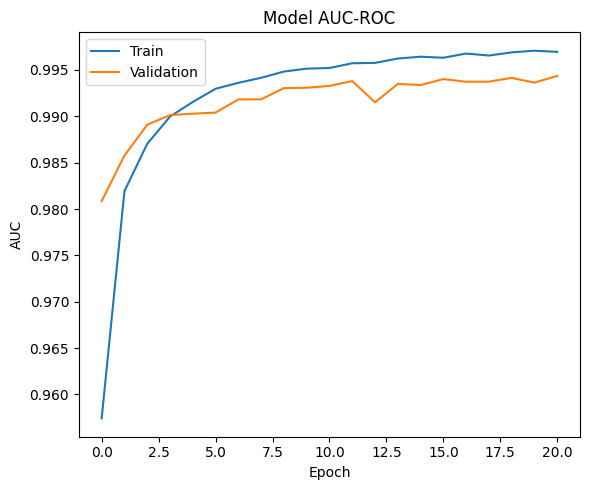

In [40]:
plotting_training(cnn_history)

68/68 [==============================] - 0s 4ms/step - loss: 0.0949 - acc: 0.9513 - auc_1: 0.9909 - false_negatives_2: 1.0000 - recall_1: 0.9991 - precision_1: 0.9131 - false_negatives_3: 1.0000 - true_negatives_1: 958.0000 - false_positives_1: 104.0000 - true_positives_1: 1093.0000
[0.09492015093564987, 0.951298713684082, 0.9909499883651733, 1.0, 0.9990859031677246, 0.9131160974502563, 1.0, 958.0, 104.0, 1093.0]
68/68 [==============================] - 0s 537us/step

=== Báo cáo Hiệu suất Mô hình trên Tập TEST ===
Tổng số mẫu trong tập TEST: 2156
Số mẫu 'Ngã' (Label 1): 1094
Số mẫu 'Không Ngã' (Label 0): 1062
--------------------------------------------------
Test Loss (từ Keras evaluate): 0.0949
Test Accuracy (từ Keras evaluate): 0.9513
Test AUC-ROC (từ Keras evaluate): 0.9909

--- Ma trận nhầm lẫn ---
True Positives (TP): 1093
True Negatives (TN): 958
False Positives (FP): 104
False Negatives (FN): 1
--------------------------------------------------
Accuracy (Manual): 0.9513
Precis

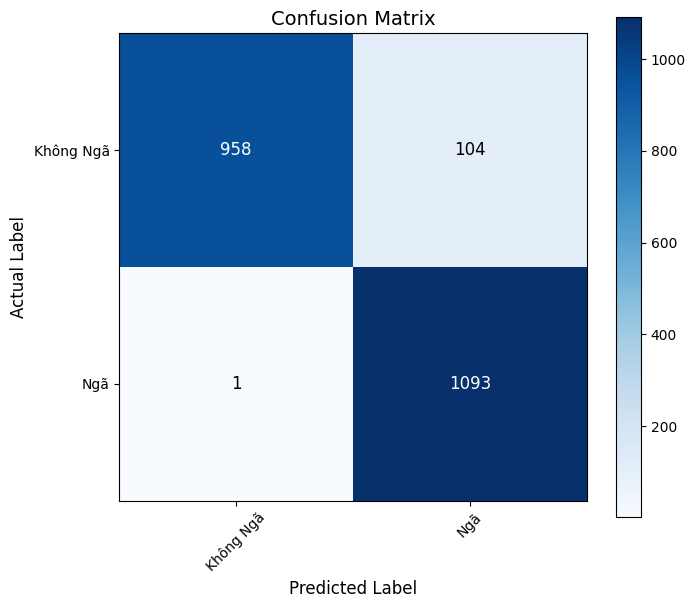

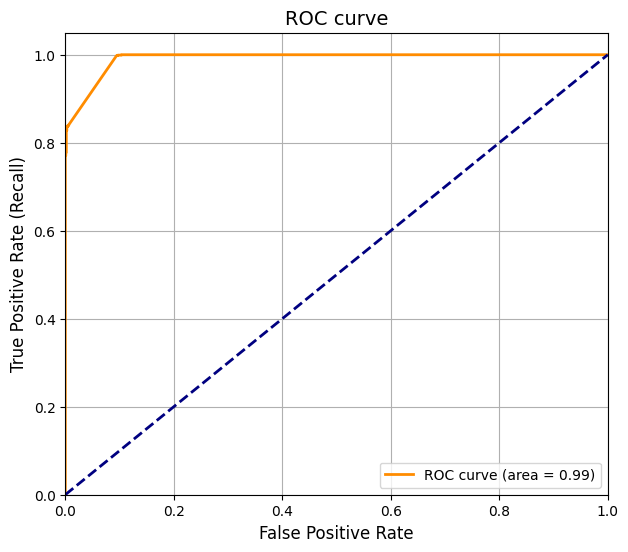

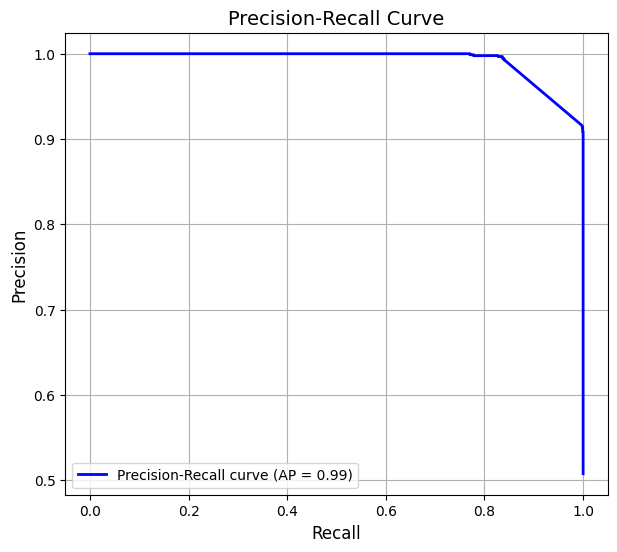

In [34]:
# test
# for cnn 2d
# x_test = []
# y_test = []

# for record in test_data:
#   x_test.append(record[1:])
#   label = int(record[0])
#   y_test.append(label) 

# x_test = array(x_test)
# x_test = x_test.reshape((len(x_test), 3, int(len(x_test[0])/3), 1))

# y_test = array(y_test)

# test_score = cnn_model.evaluate(x_test, y_test)
# print(test_score)


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score, roc_auc_score
import numpy as np

# --- Bước 1: Chuẩn bị dữ liệu Test ---
# Đảm bảo bạn đã có test_data từ một nguồn độc lập, chưa từng được mô hình nhìn thấy.
# Ví dụ:
# test_data = your_function_to_load_test_data()

x_test = []
y_test = []

for record in test_data:
  x_test.append(record[1:])
  label = int(record[0])
  y_test.append(label) 

x_test = np.array(x_test)
x_test = x_test.reshape((len(x_test), 3, int(len(x_test[0])/3), 1))

y_test = np.array(y_test)

# --- Bước 2: Đánh giá mô hình bằng model.evaluate() ---
# Lấy các metric từ quá trình compile
# Chỉ lấy các metric không bị trùng lặp và có ý nghĩa rõ ràng từ evaluate
test_results_from_evaluate = cnn_model.evaluate(x_test, y_test, verbose=1) # verbose=1 để xem tiến trình
# Bạn có thể in tên các metric để chắc chắn
# print(lstm_model.metrics_names)
print(test_results_from_evaluate)

# --- Bước 3: Tính toán các metric chi tiết từ dự đoán thô (Recommended) ---

# 1. Dự đoán xác suất trên tập kiểm tra
y_pred_proba = cnn_model.predict(x_test)

# 2. Chuyển xác suất thành nhãn dự đoán (ngưỡng 0.5 là mặc định)
y_pred_labels = (y_pred_proba > 0.5).astype(int)

# 3. Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_labels)
# cm.ravel() trả về TN, FP, FN, TP theo thứ tự này
TN, FP, FN, TP = cm.ravel()

# --- Báo cáo Text Các Metric Chính ---
print("\n" + "="*50)
print("=== Báo cáo Hiệu suất Mô hình trên Tập TEST ===")
print("="*50)
print(f"Tổng số mẫu trong tập TEST: {len(y_test)}")
print(f"Số mẫu 'Ngã' (Label 1): {np.sum(y_test == 1)}")
print(f"Số mẫu 'Không Ngã' (Label 0): {np.sum(y_test == 0)}")
print("-" * 50)

print(f"Test Loss (từ Keras evaluate): {test_results_from_evaluate[0]:.4f}")
print(f"Test Accuracy (từ Keras evaluate): {test_results_from_evaluate[1]:.4f}")
print(f"Test AUC-ROC (từ Keras evaluate): {test_results_from_evaluate[2]:.4f}") # Lấy AUC đầu tiên

print("\n--- Ma trận nhầm lẫn ---")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print("-" * 50)

# Tính toán các Metric chính xác hơn từ TP, TN, FP, FN
# Đây là các metric mà bạn nên ưu tiên để đánh giá
accuracy_manual = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_manual = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0
auc_score_manual = roc_auc_score(y_test, y_pred_proba) # Tính lại AUC để đảm bảo từ y_pred_proba

print(f"Accuracy (Manual): {accuracy_manual:.4f}")
print(f"Precision (Manual): {precision_manual:.4f}")
print(f"Recall (Độ nhạy - Rất quan trọng cho Phát hiện Ngã): {recall_manual:.4f}")
print(f"F1-Score (Manual): {f1_manual:.4f}")
print(f"AUC-ROC Score (Manual): {auc_score_manual:.4f}")
print("="*50)

# --- Trực quan hóa các Metric quan trọng ---

# Hàm vẽ Ma trận nhầm lẫn
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(7, 6)) # Tăng kích thước hình
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=10)
    plt.yticks(tick_marks, classes, fontsize=10)

    fmt = 'd' # Định dạng số nguyên
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center", fontsize=12,
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

# Hàm vẽ đường cong ROC
def plot_roc_curve(y_test, y_pred_proba, title='Receiver Operating Characteristic (ROC) Curve'):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True)
    plt.show()

# Hàm vẽ đường cong Precision-Recall
def plot_precision_recall_curve(y_test, y_pred_proba, title='Precision-Recall Curve'):
    precision_points, recall_points, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_points, precision_points)
    plt.figure(figsize=(7, 6))
    plt.plot(recall_points, precision_points, color='blue', lw=2, label=f'Precision-Recall curve (AP = {pr_auc:.2f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(True)
    plt.show()

# --- Gọi các hàm vẽ biểu đồ ---
class_names = ['Không Ngã', 'Ngã'] # Đặt tên lớp cho dễ hiểu
plot_confusion_matrix(cm, classes=class_names, title='Confusion Matrix')
plot_roc_curve(y_test, y_pred_proba, title='ROC curve')
plot_precision_recall_curve(y_test, y_pred_proba, title= 'Precision-Recall Curve')

In [27]:
# train the final lstm model with all data (include test data) 

x_train_final = []
y_train_final = []

for record in all_data:
  x_train_final.append(record[1:])
  label = int(record[0])
  y_train_final.append(label) 

final_lstm_model, final_lstm_history = train_lstm_model(x_train_final, y_train_final)

final_lstm_model.save("/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/Model_execution/new_final_lstm_model.h5")


x_train.shape (19404, 1, 63)
[[0.88876875 0.63494583 0.231903   0.90513125 0.6349625  0.352924
  0.9020375  0.6513875  0.314973   0.88669531 0.6896     0.274928
  0.87543125 0.70854583 0.358132   0.92046719 0.580525   0.324449
  0.93575937 0.59407917 0.392962   0.8815875  0.67045    0.302815
  0.92657656 0.71141667 0.125374   0.91327813 0.72499167 0.128501
  0.         0.         0.         0.         0.         0.
  0.93579219 0.686825   0.141758   0.9092     0.6457875  0.502076
  0.98489531 0.77681667 0.431155   0.99619062 0.79864167 0.10119
  0.99619062 0.79316667 0.104928   0.99615781 0.78498333 0.220742
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]]
y_train.shape (19404,)
Epoch 1/100
971/971 [==============================] - 12s 11ms/step - loss: 0.4918 - acc: 0.7665 - auc_2: 0.8437 - false_negatives_4: 1767.0000 - recall_2: 0.7728 - precision_2: 0.7639 - false_negatives_5: 1767.0000 - true_negatives_2: 5888.0000 - false_positives

Epoch 14/100
971/971 [==============================] - 10s 10ms/step - loss: 0.2721 - acc: 0.8757 - auc_2: 0.9516 - false_negatives_4: 702.0000 - recall_2: 0.9097 - precision_2: 0.8521 - false_negatives_5: 702.0000 - true_negatives_2: 6518.0000 - false_positives_2: 1228.0000 - true_positives_2: 7075.0000 - val_loss: 0.2773 - val_acc: 0.8745 - val_auc_2: 0.9534 - val_false_negatives_4: 106.0000 - val_recall_2: 0.9449 - val_precision_2: 0.8268 - val_false_negatives_5: 106.0000 - val_true_negatives_2: 1575.0000 - val_false_positives_2: 381.0000 - val_true_positives_2: 1819.0000 - lr: 7.4082e-04
Epoch 15/100
971/971 [==============================] - 10s 11ms/step - loss: 0.2674 - acc: 0.8783 - auc_2: 0.9537 - false_negatives_4: 680.0000 - recall_2: 0.9126 - precision_2: 0.8544 - false_negatives_5: 680.0000 - true_negatives_2: 6537.0000 - false_positives_2: 1209.0000 - true_positives_2: 7097.0000 - val_loss: 0.3297 - val_acc: 0.8341 - val_auc_2: 0.9447 - val_false_negatives_4: 67.0000 - v

/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/Model_execution/tfenv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
# train the final cnn model with all data (include test data) 
x_train_final = []
y_train_final = []

for record in all_data:
  x_train_final.append(record[1:])
  label = int(record[0])
  y_train_final.append(label) 

final_cnn_model, final_cnn_history = train_cnn_model(x_train_final, y_train_final)

final_cnn_model.save("/home/tungtt/Desktop/Fall_Detection_Deep_Learning_Model/Model_execution/new_final_cnn_model.h5")


Epoch 1/100
2216/2216 [==============================] - 23s 10ms/step - loss: 0.2514 - acc: 0.8973 - auc_3: 0.9614 - false_negatives_6: 1584.0000 - recall_3: 0.9107 - precision_3: 0.8870 - false_negatives_7: 1584.0000 - true_negatives_3: 15654.0000 - false_positives_3: 2057.0000 - true_positives_3: 16146.0000 - val_loss: 0.1817 - val_acc: 0.9277 - val_auc_3: 0.9821 - val_false_negatives_6: 333.0000 - val_recall_3: 0.9247 - val_precision_3: 0.9299 - val_false_negatives_7: 333.0000 - val_true_negatives_3: 4132.0000 - val_false_positives_3: 308.0000 - val_true_positives_3: 4088.0000 - lr: 0.0010
Epoch 2/100
2216/2216 [==============================] - 23s 10ms/step - loss: 0.1587 - acc: 0.9351 - auc_3: 0.9838 - false_negatives_6: 852.0000 - recall_3: 0.9519 - precision_3: 0.9209 - false_negatives_7: 852.0000 - true_negatives_3: 16262.0000 - false_positives_3: 1449.0000 - true_positives_3: 16878.0000 - val_loss: 0.1542 - val_acc: 0.9421 - val_auc_3: 0.9864 - val_false_negatives_6: 140.000

Epoch 15/100
2216/2216 [==============================] - 22s 10ms/step - loss: 0.0630 - acc: 0.9700 - auc_3: 0.9964 - false_negatives_6: 95.0000 - recall_3: 0.9946 - precision_3: 0.9480 - false_negatives_7: 95.0000 - true_negatives_3: 16744.0000 - false_positives_3: 967.0000 - true_positives_3: 17635.0000 - val_loss: 0.0850 - val_acc: 0.9661 - val_auc_3: 0.9942 - val_false_negatives_6: 21.0000 - val_recall_3: 0.9952 - val_precision_3: 0.9404 - val_false_negatives_7: 21.0000 - val_true_negatives_3: 4161.0000 - val_false_positives_3: 279.0000 - val_true_positives_3: 4400.0000 - lr: 6.7032e-04
Epoch 16/100
2216/2216 [==============================] - 21s 10ms/step - loss: 0.0607 - acc: 0.9708 - auc_3: 0.9966 - false_negatives_6: 75.0000 - recall_3: 0.9958 - precision_3: 0.9484 - false_negatives_7: 75.0000 - true_negatives_3: 16750.0000 - false_positives_3: 961.0000 - true_positives_3: 17655.0000 - val_loss: 0.0833 - val_acc: 0.9667 - val_auc_3: 0.9942 - val_false_negatives_6: 30.0000 - v